In [1]:
import kagglehub

path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import tensorflow as tf
import keras

train_ds = keras.utils.image_dataset_from_directory(
    path+"/Training",
    image_size=(224,224),
    batch_size=32,
    label_mode="int"
) 

test_ds = keras.utils.image_dataset_from_directory(
    path+"/Testing",
    image_size=(224,224),
    batch_size=32,
    label_mode="int")

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 5600 files belonging to 4 classes.
Found 1600 files belonging to 4 classes.


In [3]:
X_train, y_train, X_test, y_test = [], [], [], []

for image, label in train_ds:
	X_train.append(image)
	y_train.append(label)

for image, label in test_ds:
	X_test.append(image)
	y_test.append(label)

X_train = tf.concat(X_train,axis=0) / 255.0
y_train = tf.concat(y_train,axis=0) 
X_test = tf.concat(X_test,axis=0) / 255.0 
y_test = tf.concat(y_test,axis=0)

In [4]:
len(X_train), len(y_train), len(X_test), len(y_test)

(5600, 5600, 1600, 1600)

(<matplotlib.image.AxesImage at 0x1515c034c20>,
 <tf.Tensor: shape=(), dtype=int32, numpy=0>)

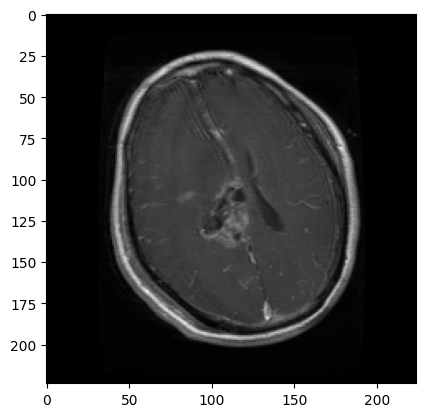

In [5]:
import matplotlib.pyplot as mtp

mtp.imshow(X_train[0]), y_train[0]

In [6]:
from keras.callbacks import EarlyStopping 
from keras import Sequential, layers
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,Dropout

In [7]:
early_stopping = keras.callbacks.EarlyStopping(monitor="val_loss",patience=5,restore_best_weights=True)

model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(224, 224, 3), padding="same"),
	MaxPooling2D((2,2)),

	Conv2D(64,(3,3),activation="relu"),
	MaxPooling2D((2,2)),

	Flatten(),

	Dense(64,activation="relu"),
	Dropout(0.5),
	Dense(32,activation="relu"),
	Dropout(0.5),
	Dense(4,activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.fit(X_train,y_train,batch_size=32,epochs=50,callbacks=[early_stopping],validation_split=0.2,shuffle=False)

Epoch 1/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 287s 2s/step - accuracy: 0.3714 - loss: 1.3601 - val_accuracy: 0.6687 - val_loss: 0.8799
Epoch 2/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 262s 2s/step - accuracy: 0.5629 - loss: 0.9582 - val_accuracy: 0.7455 - val_loss: 0.7167
Epoch 3/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 346s 2s/step - accuracy: 0.6036 - loss: 0.8500 - val_accuracy: 0.7509 - val_loss: 0.5909
Epoch 4/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 257s 2s/step - accuracy: 0.6551 - loss: 0.7383 - val_accuracy: 0.8018 - val_loss: 0.5942
Epoch 5/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 248s 2s/step - accuracy: 0.6853 - loss: 0.6766 - val_accuracy: 0.8339 - val_loss: 0.6012
Epoch 6/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 927s 7s/step - accuracy: 0.7395 - loss: 0.6120 - val_accuracy: 0.8598 - val_loss: 0.5322
Epoch 7/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 968s 7s/step - accuracy: 0.7618 - loss: 0.5621 - val_accuracy: 0.8670 - val_loss: 0.4619
Epoch 8/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 208s 1s/step - accuracy: 0.7824 - loss: 0.5149 - val_accu

In [9]:
model.evaluate(X_test,y_test)

50/50 ━━━━━━━━━━━━━━━━━━━━ 31s 606ms/step - accuracy: 0.8313 - loss: 0.8782


[0.8782079219818115, 0.831250011920929]